# Engineering Mathematics Computer Assignment
- **Name**: Shahab Sherafat
- **Student ID**: 810102467
****
If you have any questions, contact the TAs:
- **Babak Hosseini Mohtasham**:
    - *Email*: babak.hosseini.m@ut.ac.ir
    - *Telegram*: @babakstar
- **Sina**
    - *Email*: msina.parvizi@ut.ac.ir
    - *Telegram*: @Mosipamo

# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cv2
from sklearn import metrics

# Part 1: Discrete Fourier Series in 1D

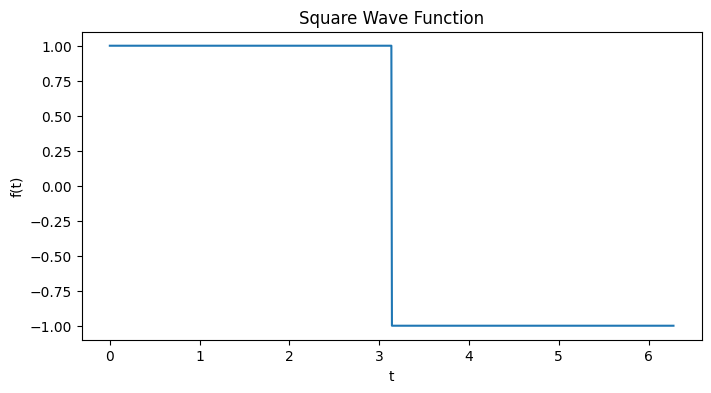

In [13]:
N = 1000

T = 2 * np.pi
t = np.linspace(0, T, N, endpoint=False)

def square_wave(t, T):
    return np.where(t % T < T/2, 1, -1)

f_t = square_wave(t, T)

plt.figure(figsize=(8, 4), dpi=100)
plt.plot(t, f_t)
plt.title("Square Wave Function")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.show()

In [ ]:
def discrete_fourier_series(f, N, n, T=T):
    if n < 0:
        return None, None
    
    t = np.linspace(0, T, N, endpoint=False)
    dt = T / N
    cos_t = np.cos(n*t)
    sin_t = np.sin(n*t)
    
    a_n = np.dot(f, cos_t) * dt * 2 / T
    a_n = a_n/2 if n == 0 else a_n
    b_n = np.dot(f, sin_t) * dt * 2 / T
    return a_n, b_n

for n in [0, 1, 2, 3, 4]:
    a_n, b_n = discrete_fourier_series(f_t, N, n)
    print(f"n={n}: a_n={a_n:.2f}, b_n={b_n:.2f}")

n=0: a_n=0.00, b_n=0.00
n=1: a_n=0.00, b_n=1.27
n=2: a_n=-0.00, b_n=0.00
n=3: a_n=0.00, b_n=0.42
n=4: a_n=0.00, b_n=0.00


If we calculate the coefficients manually, first the squared wave function is sine expanded so the cosine coefficients are going to be zero; also it is odd half-wave symmetrical so the even coefficients must be zero. Finally if we calculate the odd sinus coefficients manually we get $4/n*pi$. So the b_n for n=1 has to be around $4/pi$ which is 1.273 and for n=3 it has to be $4/(3*pi)$ which is 0.424. 

Congrats! The coefficients are true! 

Now let's reconstruct a function using its coefficients :

In [47]:
def reconstruct_function(t, a, b, T=2*np.pi):
    y_recon = np.zeros_like(t)

    for n in range(len(a)):
        y_recon += a[n] * np.cos((2 * np.pi * n * t) / T)
        y_recon += b[n] * np.sin((2 * np.pi * n * t) / T)
        
    return y_recon


Let's see how it works!

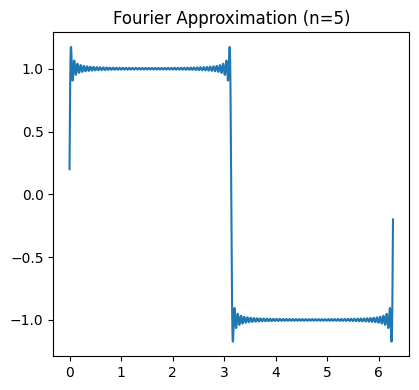

In [ ]:
a, b = [], []
for i in range(6):
    a_n, b_n = discrete_fourier_series(f_t, N, i)
    a.append(a_n)
    b.append(b_n)

y_recon_over_t = reconstruct_function(t, a, b)
    
plt.figure(figsize=(8, 4), dpi=100)
plt.subplot(1, 2, 2)
plt.plot(t, y_recon_over_t)
plt.title(f"Fourier Approximation (n={5})")
plt.tight_layout()
plt.show()

Now let's see how much effect the num of terms has on the final shape of the fourier estimation of the rectangle funciton:

Loss (n=2):
0.4352331147665207
Loss (n=5):
0.3152172633701734
Loss (n=50):
0.08965399039359621
Loss (n=100):
0.0625978705727609


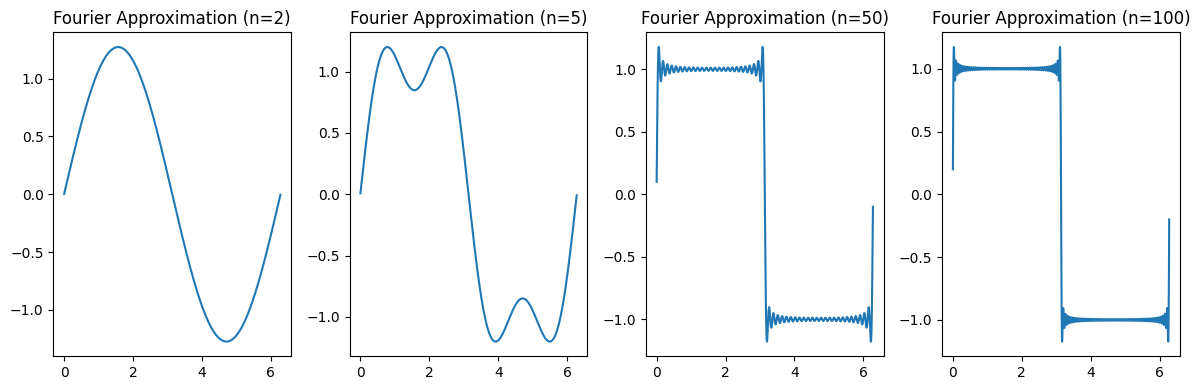

In [66]:
num_terms = [2, 5, 50, 100]
plt.figure(figsize=(3*len(num_terms), 4))

for i in range(max(num_terms)):
    a_n, b_n = discrete_fourier_series(f_t, N, i)
    a.append(a_n)
    b.append(b_n)

for i, num in enumerate(num_terms):
    plt.subplot(1, len(num_terms), i+1)
    y_recon_over_t = reconstruct_function(t, a[:num], b[:num])
    plt.plot(t, y_recon_over_t)
    plt.title(f"Fourier Approximation (n={num})")
    plt.tight_layout()

    print(f"Loss (n={num}):")
    loss = metrics.root_mean_squared_error(f_t, y_recon_over_t)
    print(loss)

plt.show()

# Part 2: Discrete Fourier Series in 2D

## Grayscale image

In [67]:
def load_grayscale_image(path, width, height):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE) / 255.0
    image = cv2.resize(image, dsize=(width, height), interpolation=cv2.INTER_CUBIC)
    return image

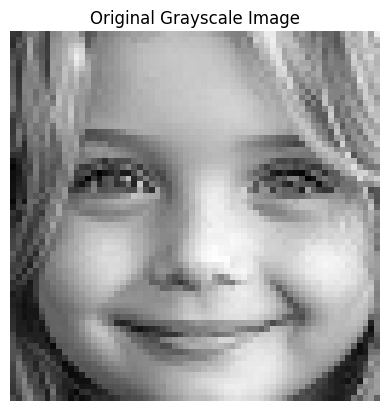

In [103]:
PATH = "./shahab.png"
image = load_grayscale_image(PATH, 64, 64)

plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.show()

In [104]:
def dft2d(image):
    M, N = image.shape
    output = np.zeros((M, N), dtype=complex)

    for k in range(M):
        for l in range(N):
            sum_val = 0
            for m in range(M):
                for n in range(N):
                    angle = -2j * np.pi * ((k * m) / M + (l * n) / N)
                    sum_val += image[m, n] * np.exp(angle)
            output[k, l] = sum_val
    return output

def idft2d(frequency_domain):
    M, N = frequency_domain.shape
    output = np.zeros((M, N), dtype=complex)

    for m in range(M):
        for n in range(N):
            sum_val = 0
            for k in range(M):
                for l in range(N):
                    angle = 2j * np.pi * ((k * m) / M + (l * n) / N)
                    sum_val += frequency_domain[k, l] * np.exp(angle)
            output[m, n] = sum_val / (M * N)
    return output

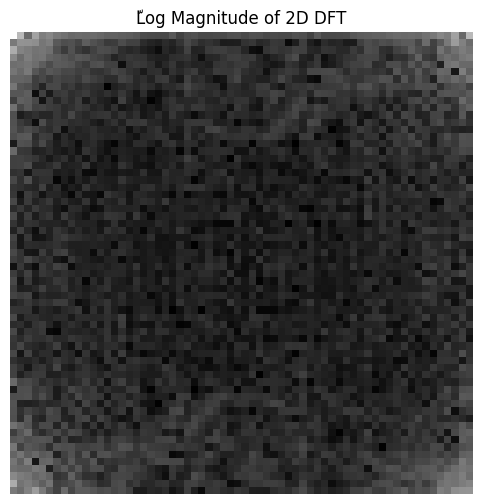

In [106]:
F = dft2d(image)

plt.figure(figsize=(15, 6))
log_magnitude_dft = np.log(1 + np.abs(F))

plt.imshow(log_magnitude_dft, cmap='gray')
plt.title('ّLog Magnitude of 2D DFT')
plt.axis('off')
plt.show()

In [107]:
def compress_image(F, fraction):
    rows, cols = F.shape
    keep_rows = int(rows * fraction**(1/2))
    keep_cols = int(cols * fraction**(1/2))
    
    mask = np.zeros_like(F, dtype=bool)
    mask[:keep_rows, :keep_cols] = True
    compressed_F = np.zeros_like(F, dtype=complex)
    compressed_F[mask] = F[mask]

    return compressed_F

To compress the image, we have to take some of the coefficients. As we know, in the fourier transform lower frequencies are more effective on the final decompressed image. So I start from the top left point of the coefficients and take a rectangle of the coefficients; becuase the frequencies have linear relationship with the l and k in the formula. 

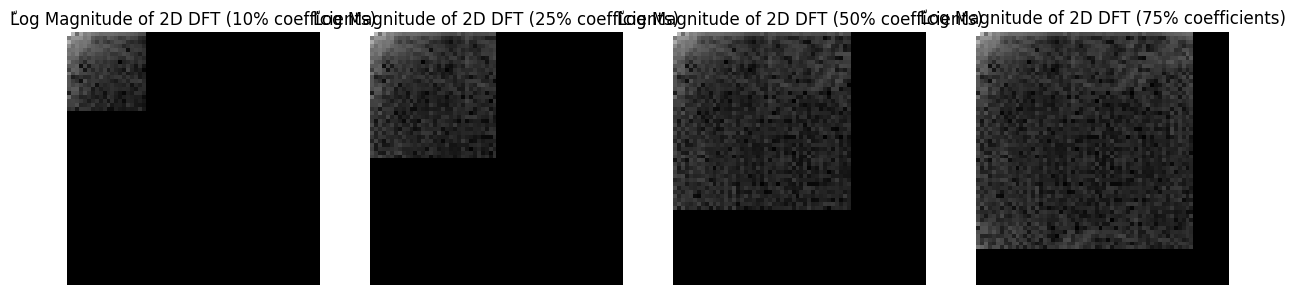

In [108]:
fractions = [0.1, 0.25, 0.5, 0.75]
plt.figure(figsize=(15, 6))

for i, frac in enumerate(fractions):
    plt.subplot(1, len(fractions), i + 1)
    
    compressed_F = compress_image(F, frac)
    log_magnitude_dft = np.log(1 + np.abs(compressed_F))
    
    plt.imshow(log_magnitude_dft, cmap='gray')
    plt.title(f'ّLog Magnitude of 2D DFT ({frac *100:.0f}% coefficients)')
    plt.axis('off')
    
plt.show()

Loss (25% coefficients):
rmse:  0.11563870976570766
mae:  0.0931923416847457
Loss (50% coefficients):
rmse:  0.11292603462933314
mae:  0.09139570214019804
Loss (75% coefficients):
rmse:  0.10806928856642399
mae:  0.08748917522272473
Loss (100% coefficients):
rmse:  7.406106772056212e-15
mae:  5.362736689722321e-15


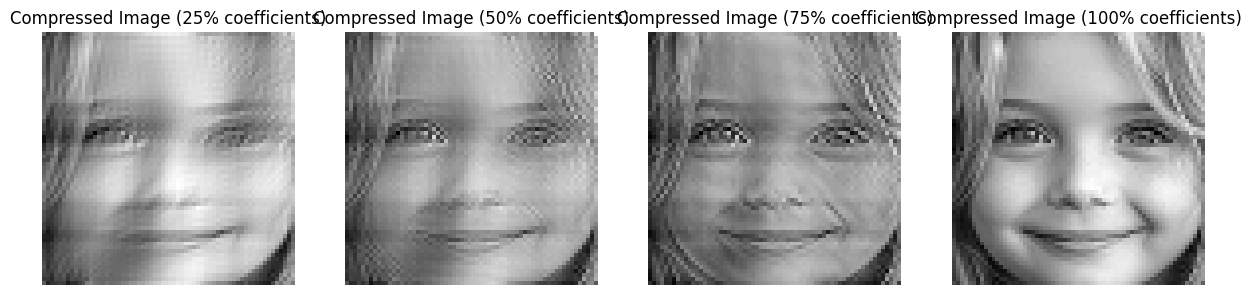

In [109]:
fractions = [0.25, 0.5, 0.75, 1]
plt.figure(figsize=(15, 6))

for i, frac in enumerate(fractions):
    compressed_F = compress_image(F, frac)
    reconstructed_image = np.abs(idft2d(compressed_F))

    plt.subplot(1, len(fractions), i + 1)
    plt.imshow(reconstructed_image, cmap='gray')
    plt.title(f'Compressed Image ({frac *100:.0f}% coefficients)')
    plt.axis('off')
    
    print(f"Loss ({frac *100:.0f}% coefficients):")
    print("rmse: ", metrics.root_mean_squared_error(image.flatten(), reconstructed_image.flatten()))
    print("mae: ", metrics.mean_absolute_error(image.flatten(), reconstructed_image.flatten()))
    
plt.show()

## Colored image

In [110]:
def load_image(path, width, height):
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, dsize=(width, height),
                       interpolation=cv2.INTER_CUBIC) / 255.0
    return image

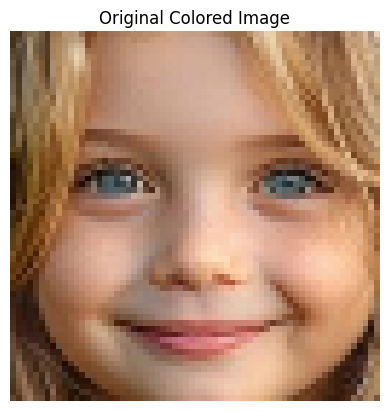

In [111]:
image = load_image(PATH, 64, 64)
F_rgb = np.zeros_like(image, dtype=complex)

plt.imshow(image, cmap='gray')
plt.title('Original Colored Image')
plt.axis('off')

plt.show()

Loss (10% coefficients):
rmse:  0.12111502461786396
mae:  0.09772373337931846
Loss (25% coefficients):
rmse:  0.11884097721231862
mae:  0.09633186071926812
Loss (50% coefficients):
rmse:  0.11608967771685587
mae:  0.09450357324860052
Loss (75% coefficients):
rmse:  0.11112382226070507
mae:  0.0904105021326921


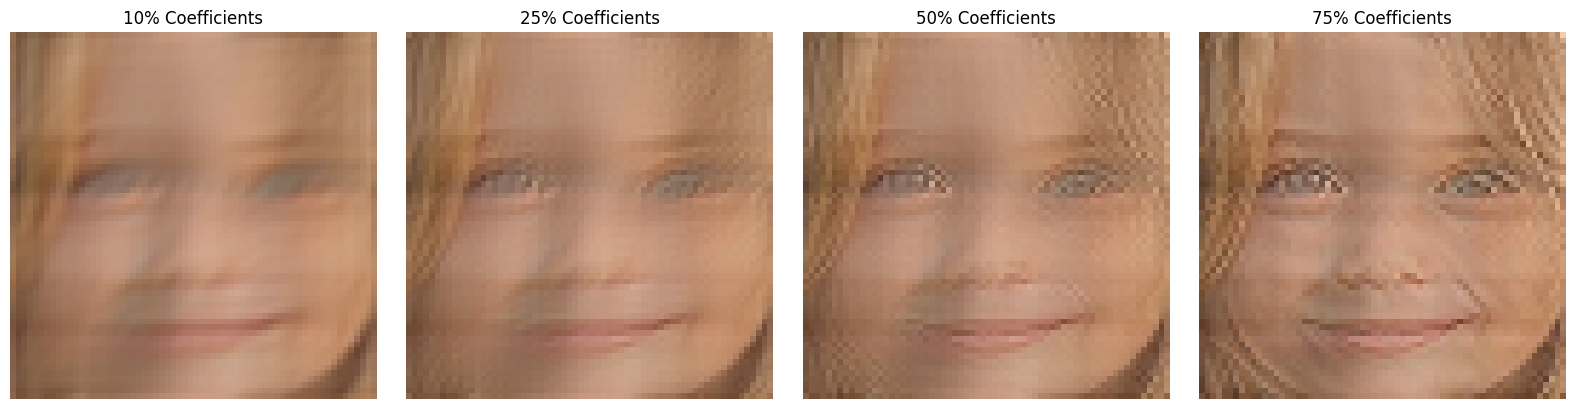

In [112]:
fractions = [0.1, 0.25, 0.5, 0.75]

plt.figure(figsize=(4 * len(fractions), 4))

for i, frac in enumerate(fractions):
    reconstructed_channels = []

    for c in range(3):
        F = dft2d(image[:, :, c])
        F_compressed = compress_image(F, frac)
        channel_recon = np.abs(idft2d(F_compressed))
        channel_recon = np.clip(channel_recon, 0, 1)
        reconstructed_channels.append(channel_recon)

    reconstructed_image = np.stack(reconstructed_channels, axis=2)

    plt.subplot(1, len(fractions), i + 1)
    plt.imshow(reconstructed_image)
    plt.title(f'{int(frac*100)}% Coefficients')
    plt.axis('off')

    print(f"Loss ({frac * 100:.0f}% coefficients):")
    print("rmse: ", metrics.root_mean_squared_error(image.flatten(), reconstructed_image.flatten()))
    print("mae: ", metrics.mean_absolute_error(image.flatten(), reconstructed_image.flatten()))

plt.tight_layout()
plt.show()
